In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# !pip install xgboost imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE

print("✅ All libraries imported successfully")


✅ All libraries imported successfully


In [6]:
# Upload your CSV first in Colab, then run:
# from google.colab import files
# uploaded = files.upload()   # select credit_card_frauds.csv

df = pd.read_csv('/content/credit_card_frauds.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['is_fraud'].value_counts()}")
print(f"\nFraud rate: {df['is_fraud'].mean()*100:.4f}%")


Dataset shape: (339607, 15)

Class distribution:
is_fraud
0    337825
1      1782
Name: count, dtype: int64

Fraud rate: 0.5247%


In [7]:
# ── Feature Engineering ──────────────────────────────────────
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob']                   = pd.to_datetime(df['dob'])

df['hour']         = df['trans_date_trans_time'].dt.hour
df['day_of_week']  = df['trans_date_trans_time'].dt.dayofweek
df['month']        = df['trans_date_trans_time'].dt.month
df['age']          = (df['trans_date_trans_time'] - df['dob']).dt.days // 365
df['distance_km']  = np.sqrt(
                        (df['lat'] - df['merch_lat'])**2 +
                        (df['long'] - df['merch_long'])**2
                     ) * 111
df['log_amt']      = np.log1p(df['amt'])
df['is_night']     = ((df['hour'] < 6) | (df['hour'] >= 22)).astype(int)
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
df['category_enc'] = LabelEncoder().fit_transform(df['category'])
df['state_enc']    = LabelEncoder().fit_transform(df['state'])

FEATURES = ['amt', 'log_amt', 'hour', 'day_of_week', 'month', 'age',
            'distance_km', 'city_pop', 'is_night', 'is_weekend',
            'category_enc', 'state_enc']
TARGET = 'is_fraud'

print(f"\n✅ Feature engineering complete — {len(FEATURES)} features ready")
print("Features:", FEATURES)



✅ Feature engineering complete — 12 features ready
Features: ['amt', 'log_amt', 'hour', 'day_of_week', 'month', 'age', 'distance_km', 'city_pop', 'is_night', 'is_weekend', 'category_enc', 'state_enc']


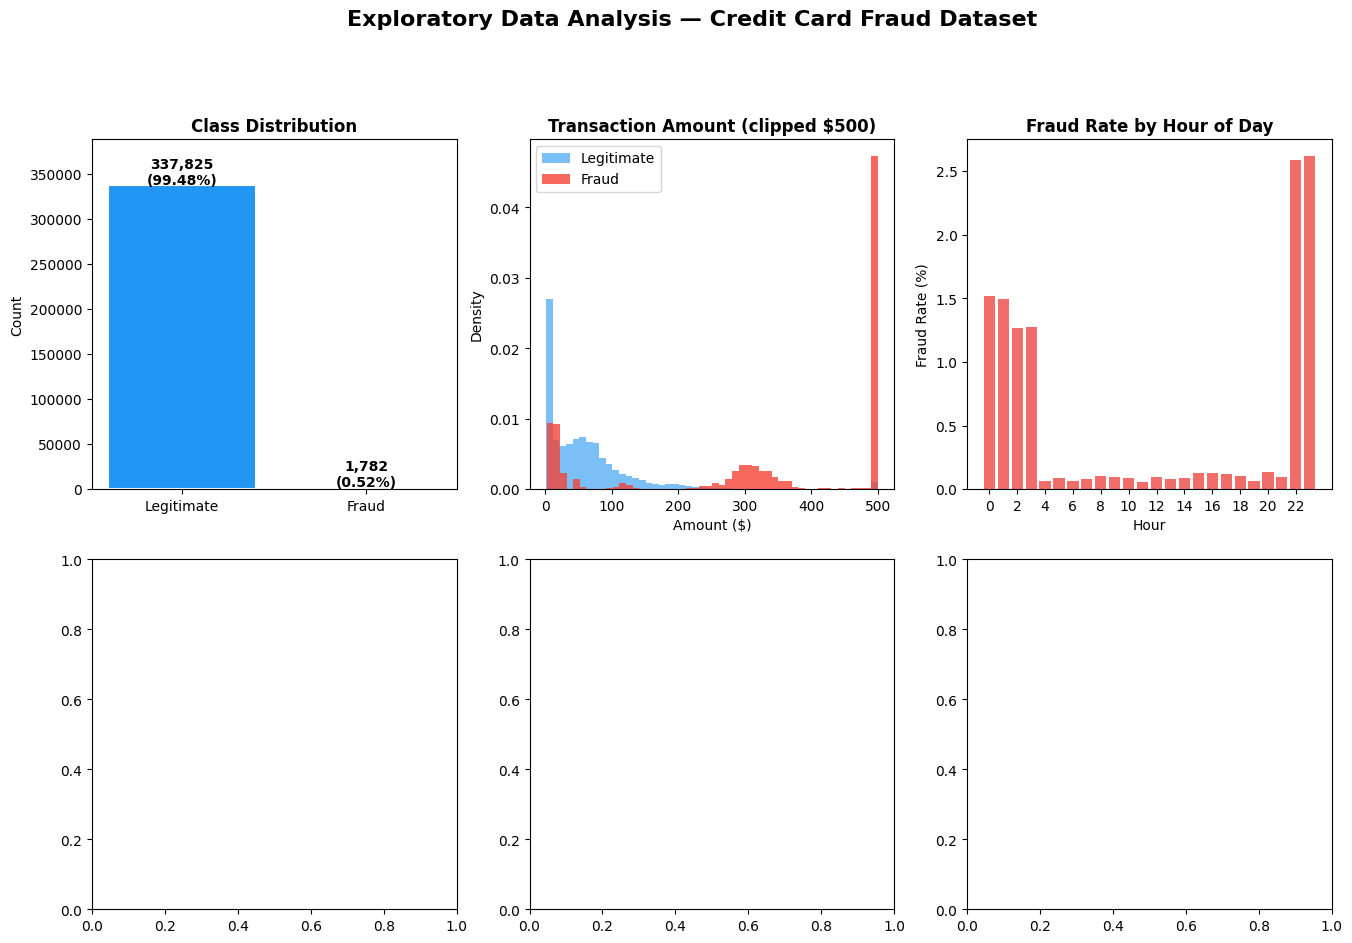

In [8]:
# CELL 3 — EDA Plots
# ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Exploratory Data Analysis — Credit Card Fraud Dataset',
             fontsize=16, fontweight='bold', y=1.01)

# 1 — Class imbalance
counts = df['is_fraud'].value_counts()
axes[0,0].bar(['Legitimate', 'Fraud'], counts.values,
              color=['#2196F3', '#F44336'], edgecolor='white', linewidth=1.5)
for i, v in enumerate(counts.values):
    axes[0,0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.2f}%)',
                   ha='center', fontsize=10, fontweight='bold')
axes[0,0].set_title('Class Distribution', fontweight='bold')
axes[0,0].set_ylabel('Count')
axes[0,0].set_ylim(0, max(counts) * 1.15)

# 2 — Amount distribution by class
fraud_amt = df[df['is_fraud']==1]['amt']
legit_amt = df[df['is_fraud']==0]['amt']
axes[0,1].hist(legit_amt.clip(upper=500), bins=50, alpha=0.6,
               color='#2196F3', label='Legitimate', density=True)
axes[0,1].hist(fraud_amt.clip(upper=500), bins=50, alpha=0.8,
               color='#F44336', label='Fraud', density=True)
axes[0,1].set_title('Transaction Amount (clipped $500)', fontweight='bold')
axes[0,1].set_xlabel('Amount ($)')
axes[0,1].set_ylabel('Density')
axes[0,1].legend()

# 3 — Hourly fraud rate
hourly = df.groupby('hour')['is_fraud'].agg(['sum', 'count'])
hourly['rate'] = hourly['sum'] / hourly['count'] * 100
axes[0,2].bar(hourly.index, hourly['rate'], color='#EF5350', alpha=0.85)
axes[0,2].set_title('Fraud Rate by Hour of Day', fontweight='bold')
axes[0,2].set_xlabel('Hour')
axes[0,2].set_ylabel('Fraud Rate (%)')
axes[0,2].set_xticks(range(0, 24, 2))



In [9]:
# 4 — Category fraud rate
cat_fraud = df.groupby('category')['is_fraud'].mean().sort_values(ascending=True) * 100
axes[1,0].barh(cat_fraud.index, cat_fraud.values, color='#42A5F5')
axes[1,0].set_title('Fraud Rate by Category', fontweight='bold')
axes[1,0].set_xlabel('Fraud Rate (%)')
for i, v in enumerate(cat_fraud.values):
    axes[1,0].text(v + 0.01, i, f'{v:.2f}%', va='center', fontsize=8)


In [10]:
# 5 — Amount boxplot
axes[1,1].boxplot([legit_amt, fraud_amt],
                  labels=['Legitimate', 'Fraud'],
                  patch_artist=True,
                  boxprops=dict(facecolor='#BBDEFB'),
                  medianprops=dict(color='#1565C0', linewidth=2))
axes[1,1].set_ylabel('Amount ($)')
axes[1,1].set_yscale('log')
axes[1,1].set_title('Amount Distribution (log scale)', fontweight='bold')


Text(0.5, 1.0, 'Amount Distribution (log scale)')

In [11]:
# 6 — Correlation heatmap
corr = df[FEATURES + ['is_fraud']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1,2], annot_kws={'size': 7}, linewidths=0.5)
axes[1,2].set_title('Feature Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots displayed and saved as eda_plots.png")


<Figure size 640x480 with 0 Axes>

✅ EDA plots displayed and saved as eda_plots.png


In [12]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE:")
print(f"  Train — Total: {len(X_train):,}  |  Fraud: {y_train.sum():,}  |  Rate: {y_train.mean()*100:.3f}%")
print(f"  Test  — Total: {len(X_test):,}   |  Fraud: {y_test.sum():,}   |  Rate: {y_test.mean()*100:.3f}%")

# Apply SMOTE ONLY on training set
sm = SMOTE(random_state=42, sampling_strategy=0.1)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE (training only):")
print(f"  Train — Total: {len(X_train_sm):,}  |  Fraud: {y_train_sm.sum():,}  |  Rate: {y_train_sm.mean()*100:.3f}%")
print(f"  Test set unchanged — Real-world distribution preserved ✅")


Before SMOTE:
  Train — Total: 271,685  |  Fraud: 1,426  |  Rate: 0.525%
  Test  — Total: 67,922   |  Fraud: 356   |  Rate: 0.524%

After SMOTE (training only):
  Train — Total: 297,284  |  Fraud: 27,025  |  Rate: 9.091%
  Test set unchanged — Real-world distribution preserved ✅


In [13]:
# CELL 5 — Train All 4 Models + Print Results Table
# ────────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, class_weight='balanced', random_state=42),

    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=12, class_weight='balanced',
        n_jobs=-1, random_state=42),

    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=10, eval_metric='logloss',
        n_jobs=-1, random_state=42),
}

results  = {}
probas   = {}
preds    = {}

print("Training models...\n")
print(f"{'Model':<22} {'AUC-ROC':>8} {'PR-AUC':>8} {'F1':>8} {'Precision':>10} {'Recall':>8}")
print("─" * 68)

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    proba = model.predict_proba(X_test)[:, 1]
    pred  = (proba >= 0.5).astype(int)

    probas[name] = proba
    preds[name]  = pred

    results[name] = {
        'AUC-ROC':   round(roc_auc_score(y_test, proba), 4),
        'PR-AUC':    round(average_precision_score(y_test, proba), 4),
        'F1':        round(f1_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall':    round(recall_score(y_test, pred), 4),
    }

    r = results[name]
    print(f"{name:<22} {r['AUC-ROC']:>8.4f} {r['PR-AUC']:>8.4f} "
          f"{r['F1']:>8.4f} {r['Precision']:>10.4f} {r['Recall']:>8.4f}")

print("─" * 68)
print("\n✅ All models trained")

# Print full classification report for XGBoost
print("\n── XGBoost Classification Report (threshold = 0.5) ──")
print(classification_report(y_test, preds['XGBoost'],
                             target_names=['Legitimate', 'Fraud']))


Training models...

Model                   AUC-ROC   PR-AUC       F1  Precision   Recall
────────────────────────────────────────────────────────────────────
Logistic Regression      0.9119   0.1603   0.1112     0.0601   0.7444
Decision Tree            0.9654   0.3582   0.2004     0.1125   0.9185
Random Forest            0.9838   0.7408   0.4633     0.3207   0.8343
XGBoost                  0.9956   0.8633   0.5878     0.4380   0.8933
────────────────────────────────────────────────────────────────────

✅ All models trained

── XGBoost Classification Report (threshold = 0.5) ──
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00     67566
       Fraud       0.44      0.89      0.59       356

    accuracy                           0.99     67922
   macro avg       0.72      0.94      0.79     67922
weighted avg       1.00      0.99      0.99     67922



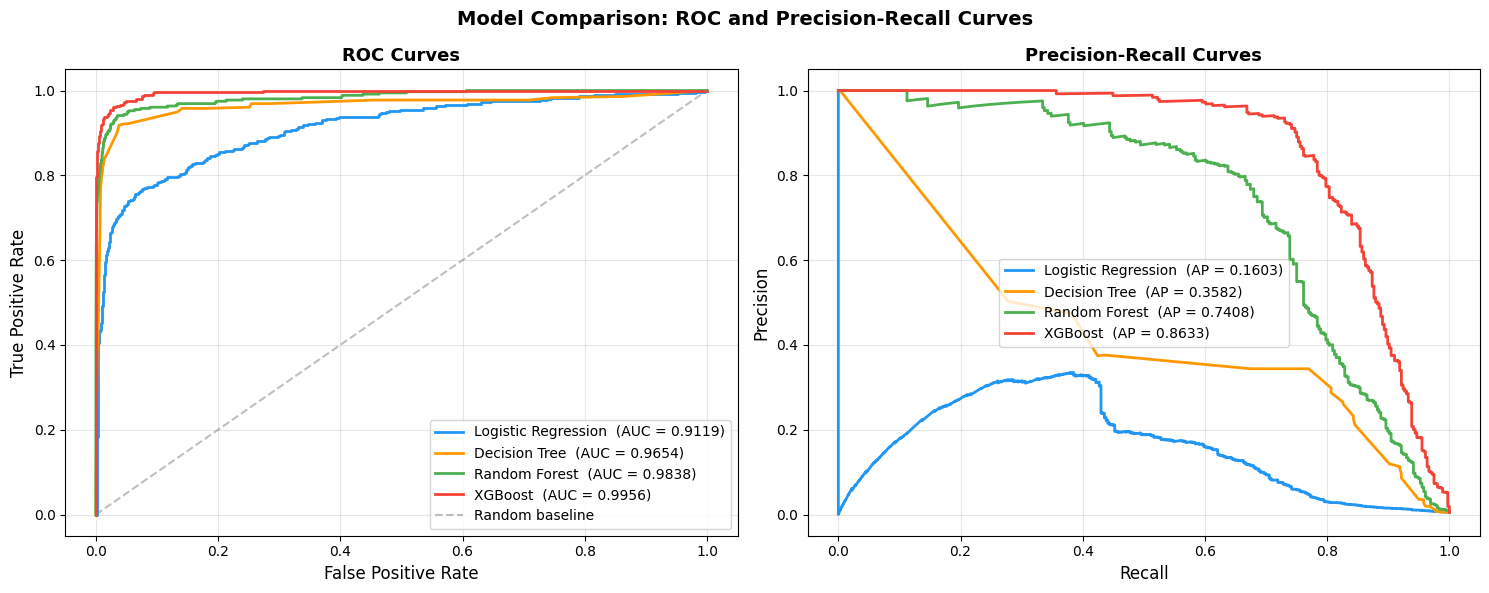

✅ ROC and Precision-Recall curves displayed


In [14]:
# CELL 6 — ROC Curves + Precision-Recall Curves
# ────────────────────────────────────────────────────────────
COLOURS = {
    'Logistic Regression': '#2196F3',
    'Decision Tree':       '#FF9800',
    'Random Forest':       '#4CAF50',
    'XGBoost':             '#F44336',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Model Comparison: ROC and Precision-Recall Curves',
             fontsize=14, fontweight='bold')

# ── ROC curves ───────────────────────────────────────────────
for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name}  (AUC = {auc:.4f})',
                 color=COLOURS[name], linewidth=2)

axes[0].plot([0, 1], [0, 1], '--', color='grey', alpha=0.5, label='Random baseline')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# ── Precision-Recall curves ───────────────────────────────────
for name, proba in probas.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, label=f'{name}  (AP = {ap:.4f})',
                 color=COLOURS[name], linewidth=2)

axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC and Precision-Recall curves displayed")


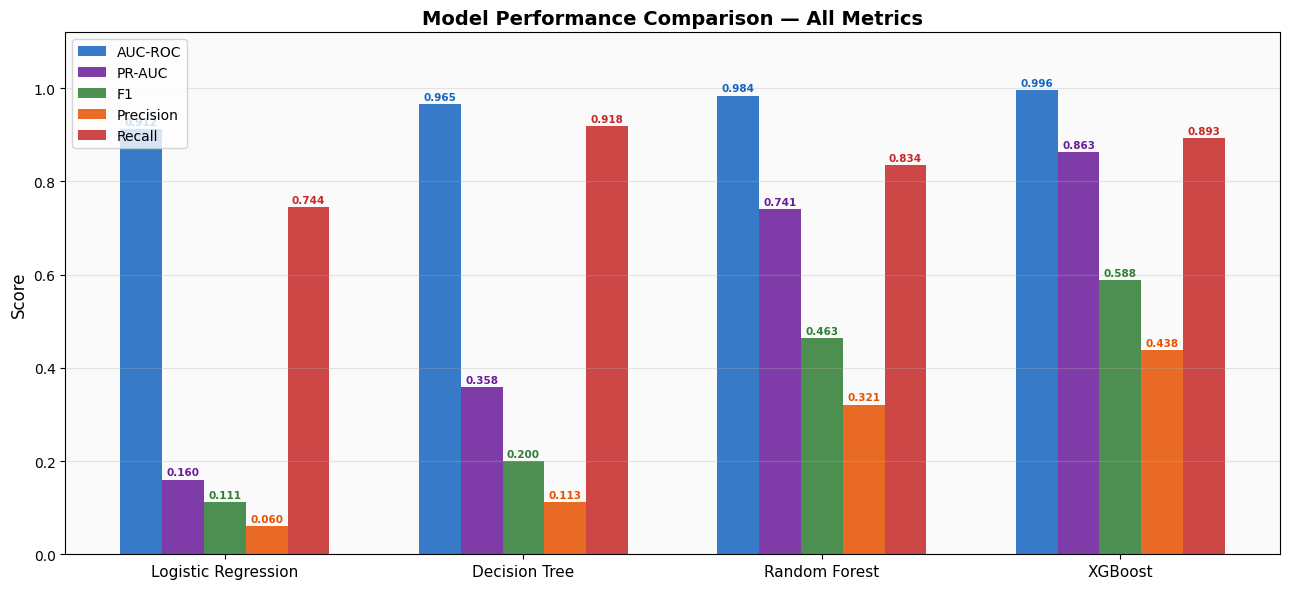

✅ Metrics comparison chart displayed

Full results table:
                     AUC-ROC  PR-AUC      F1  Precision  Recall
Logistic Regression   0.9119  0.1603  0.1112     0.0601  0.7444
Decision Tree         0.9654  0.3582  0.2004     0.1125  0.9185
Random Forest         0.9838  0.7408  0.4633     0.3207  0.8343
XGBoost               0.9956  0.8633  0.5878     0.4380  0.8933


In [15]:
# CELL 7 — Metrics Comparison Bar Chart
# ────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).T
metric_cols = ['AUC-ROC', 'PR-AUC', 'F1', 'Precision', 'Recall']
bar_colours = ['#1565C0', '#6A1B9A', '#2E7D32', '#E65100', '#C62828']

x     = np.arange(len(results_df))
width = 0.14

fig, ax = plt.subplots(figsize=(13, 6))
for i, (col, colour) in enumerate(zip(metric_cols, bar_colours)):
    bars = ax.bar(x + i * width, results_df[col], width,
                  label=col, color=colour, alpha=0.85)
    # Value labels on top of each bar
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7.5,
                fontweight='bold', color=colour)

ax.set_xticks(x + 2 * width)
ax.set_xticklabels(results_df.index, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_title('Model Performance Comparison — All Metrics',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Metrics comparison chart displayed")
print("\nFull results table:")
print(results_df.to_string())



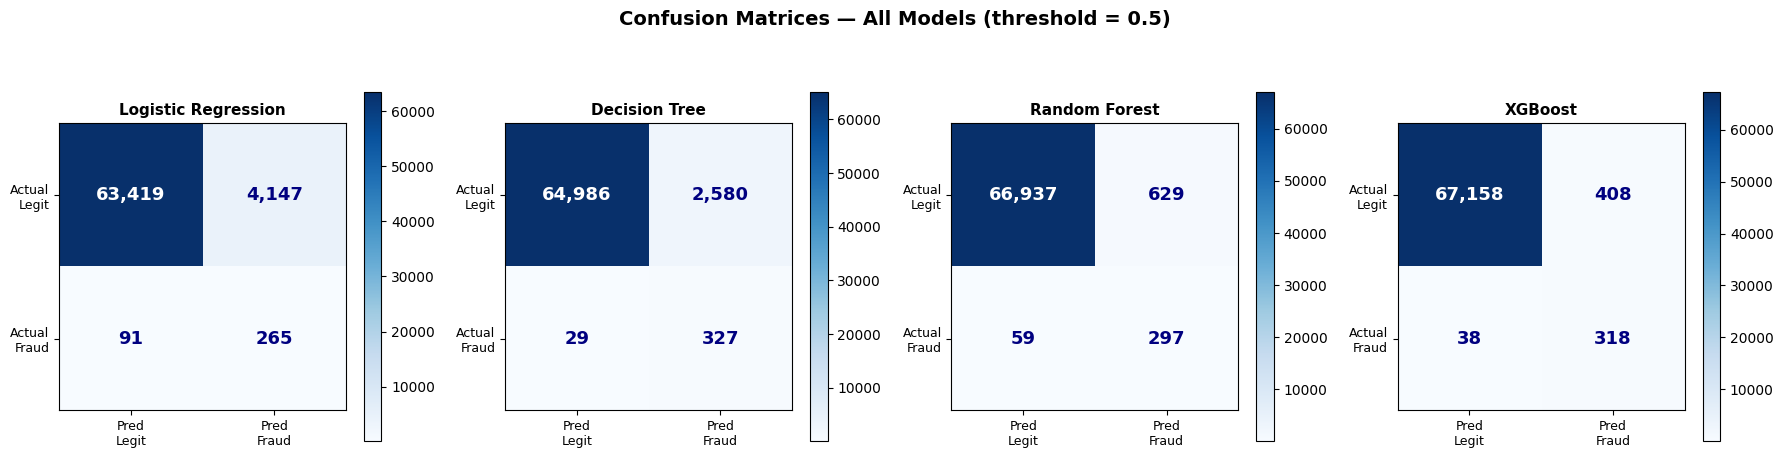

✅ Confusion matrices displayed


In [16]:
# CELL 8 — Confusion Matrices for All 4 Models
# ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Confusion Matrices — All Models (threshold = 0.5)',
             fontsize=14, fontweight='bold')

for ax, (name, pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, pred)
    im = ax.imshow(cm, cmap='Blues')

    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i, j]:,}',
                    ha='center', va='center',
                    fontsize=13, fontweight='bold',
                    color='white' if cm[i, j] > cm.max() / 2 else 'navy')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred\nLegit', 'Pred\nFraud'], fontsize=9)
    ax.set_yticklabels(['Actual\nLegit', 'Actual\nFraud'], fontsize=9)
    ax.set_title(name, fontweight='bold', fontsize=11)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices displayed")



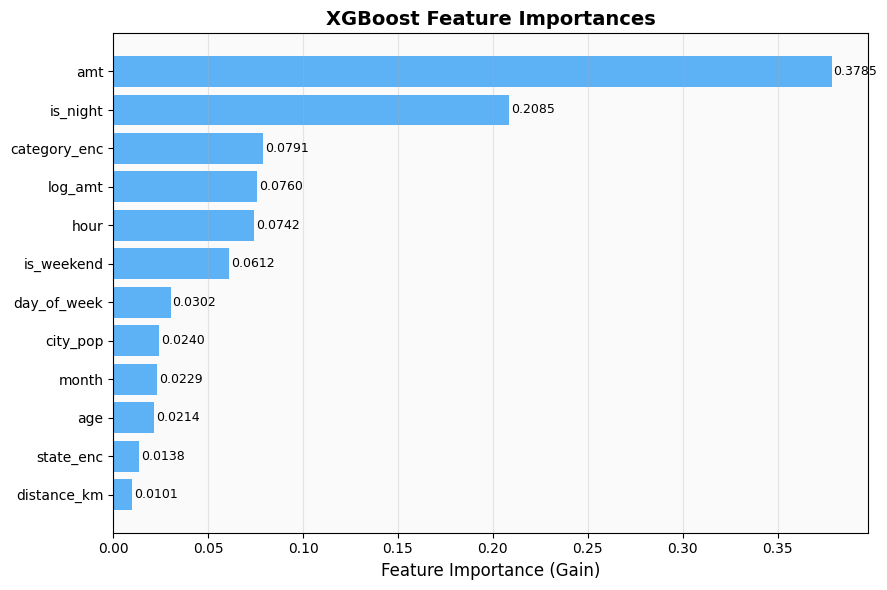


Feature importances (sorted):
     Feature  Importance
         amt    0.378527
    is_night    0.208464
category_enc    0.079117
     log_amt    0.075999
        hour    0.074226
  is_weekend    0.061160
 day_of_week    0.030197
    city_pop    0.024045
       month    0.022941
         age    0.021381
   state_enc    0.013833
 distance_km    0.010111


In [17]:
# CELL 9 — XGBoost Feature Importances
# ────────────────────────────────────────────────────────────
xgb_model    = models['XGBoost']
importances  = xgb_model.feature_importances_
idx          = np.argsort(importances)  # ascending for horizontal bar

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(np.array(FEATURES)[idx], importances[idx],
               color='#42A5F5', alpha=0.85)

# Value labels
for bar, val in zip(bars, importances[idx]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance (Gain)', fontsize=12)
ax.set_title('XGBoost Feature Importances', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature importances (sorted):")
fi_df = pd.DataFrame({'Feature': FEATURES,
                       'Importance': importances}
                     ).sort_values('Importance', ascending=False)
print(fi_df.to_string(index=False))



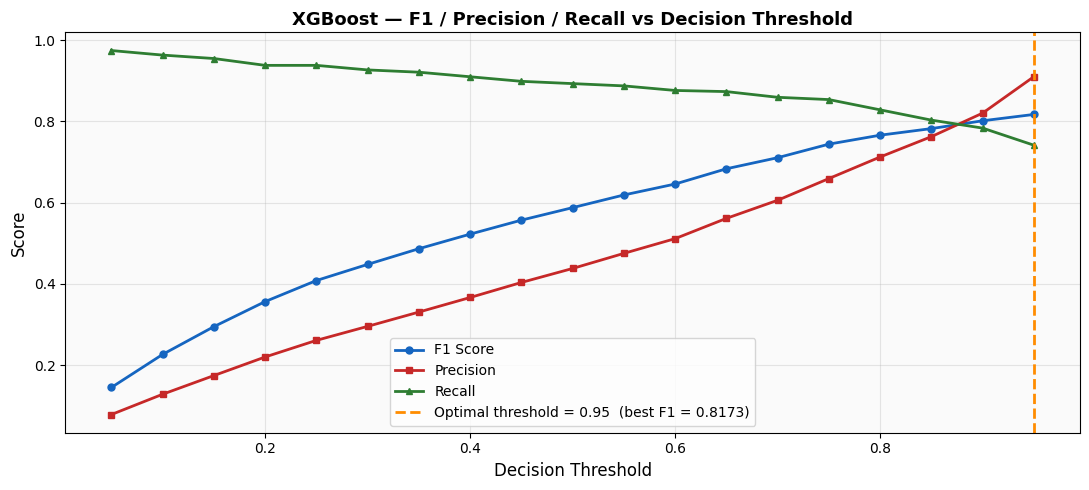


Optimal threshold: 0.95
  F1-Score  : 0.8173
  Precision : 0.9103
  Recall    : 0.7416

── XGBoost Classification Report (threshold = 0.95) ──
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     67566
       Fraud       0.91      0.74      0.82       356

    accuracy                           1.00     67922
   macro avg       0.95      0.87      0.91     67922
weighted avg       1.00      1.00      1.00     67922


── Threshold Comparison ──
 Threshold  Precision   Recall       F1
──────────────────────────────────────────
      0.05     0.0783   0.9747   0.1450
      0.10     0.1283   0.9635   0.2264
      0.15     0.1743   0.9551   0.2948
      0.20     0.2200   0.9382   0.3565
      0.25     0.2609   0.9382   0.4083
      0.30     0.2954   0.9270   0.4481
      0.35     0.3306   0.9213   0.4866
      0.40     0.3665   0.9101   0.5226
      0.45     0.4035   0.8989   0.5570
      0.50     0.4380   0.8933   0.5878
      0.55     0.4

In [18]:
# CELL 10 — Decision Threshold Optimisation (XGBoost)
# ────────────────────────────────────────────────────────────
xgb_proba  = probas['XGBoost']
thresholds = np.arange(0.05, 0.96, 0.05)

f1s, precs, recs = [], [], []
for t in thresholds:
    p = (xgb_proba >= t).astype(int)
    f1s.append(  f1_score(y_test,        p, zero_division=0))
    precs.append(precision_score(y_test, p, zero_division=0))
    recs.append( recall_score(y_test,    p, zero_division=0))

best_idx = int(np.argmax(f1s))
best_t   = thresholds[best_idx]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds, f1s,   '-o', label='F1 Score',  color='#1565C0',
        linewidth=2, markersize=5)
ax.plot(thresholds, precs, '-s', label='Precision',  color='#C62828',
        linewidth=2, markersize=5)
ax.plot(thresholds, recs,  '-^', label='Recall',     color='#2E7D32',
        linewidth=2, markersize=5)

ax.axvline(x=best_t, color='darkorange', linestyle='--', linewidth=2,
           label=f'Optimal threshold = {best_t:.2f}  (best F1 = {f1s[best_idx]:.4f})')

ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Score',              fontsize=12)
ax.set_title('XGBoost — F1 / Precision / Recall vs Decision Threshold',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('threshold_optimisation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOptimal threshold: {best_t:.2f}")
print(f"  F1-Score  : {f1s[best_idx]:.4f}")
print(f"  Precision : {precs[best_idx]:.4f}")
print(f"  Recall    : {recs[best_idx]:.4f}")

# Print results at optimal threshold
best_pred = (xgb_proba >= best_t).astype(int)
print(f"\n── XGBoost Classification Report (threshold = {best_t:.2f}) ──")
print(classification_report(y_test, best_pred,
                             target_names=['Legitimate', 'Fraud']))

# Threshold comparison table
print(f"\n── Threshold Comparison ──")
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("─" * 42)
for t, p, r, f in zip(thresholds, precs, recs, f1s):
    marker = " ◄ OPTIMAL" if abs(t - best_t) < 0.001 else ""
    print(f"{t:>10.2f} {p:>10.4f} {r:>8.4f} {f:>8.4f}{marker}")



Text(0.5, 1.0, 'XGBoost Confusion Matrix\n(threshold=0.5)')

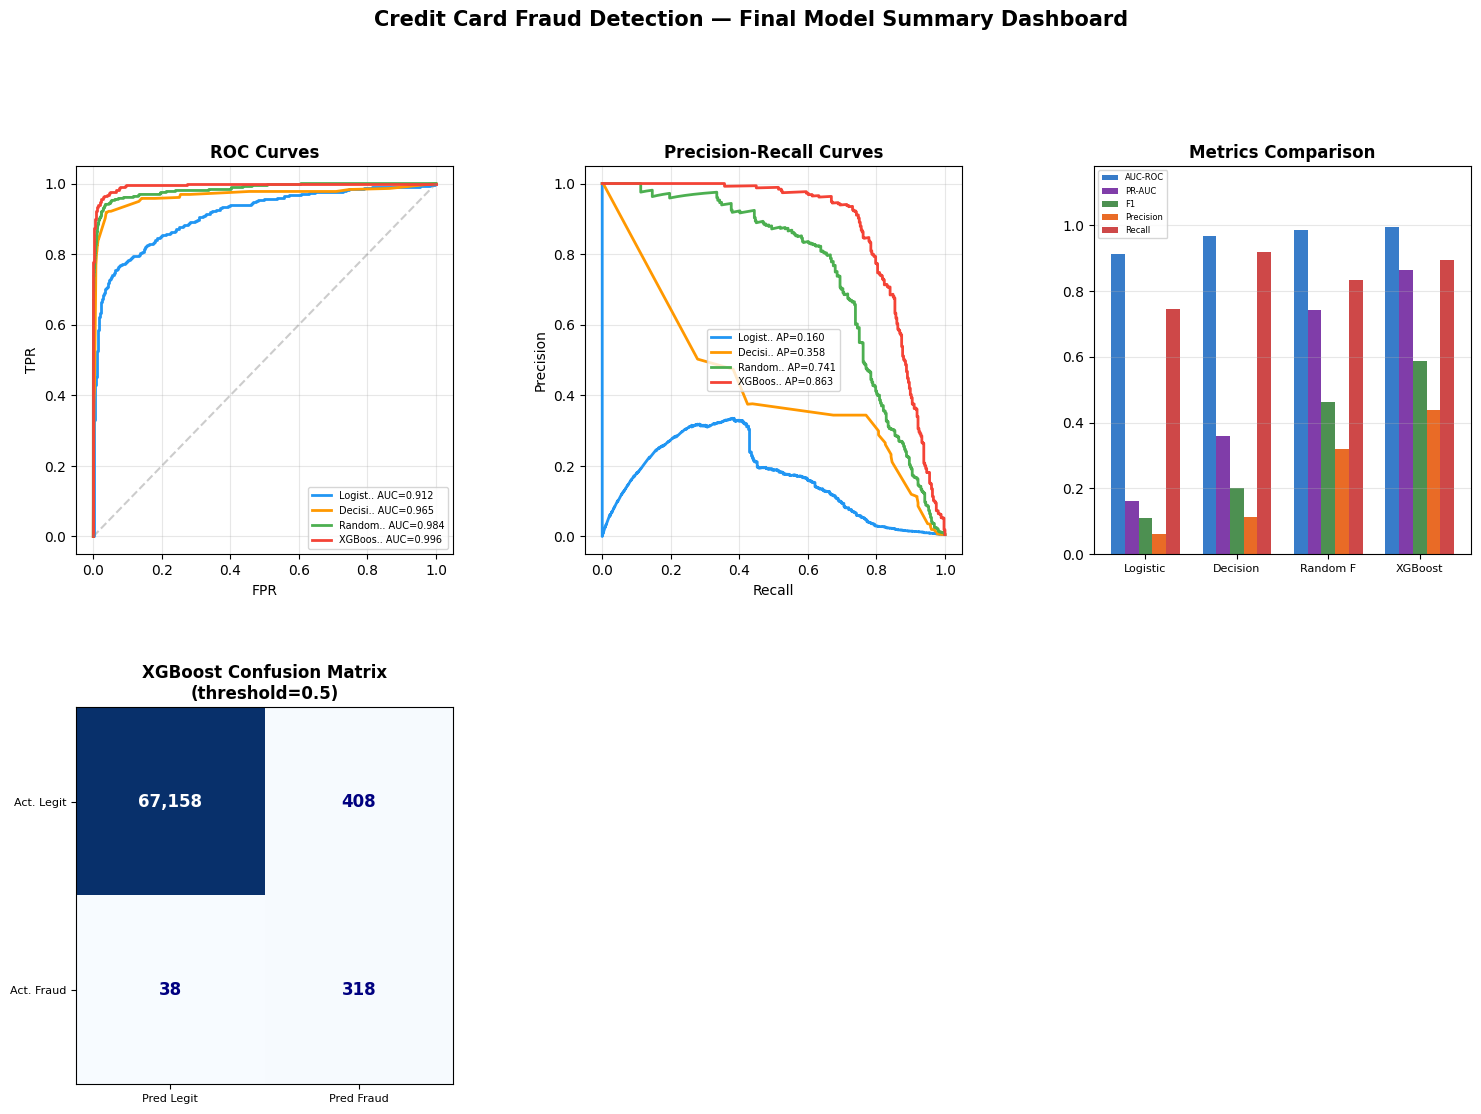

In [19]:
# CELL 11 — Final Summary Dashboard (all charts in one figure)
# ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Credit Card Fraud Detection — Final Model Summary Dashboard',
             fontsize=15, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)

# ── Panel A: ROC curves ───────────────────────────────────────
ax_roc = fig.add_subplot(gs[0, 0])
for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax_roc.plot(fpr, tpr, label=f'{name[:6]}.. AUC={auc:.3f}',
                color=COLOURS[name], lw=2)
ax_roc.plot([0,1],[0,1],'--',color='grey',alpha=0.4)
ax_roc.set_title('ROC Curves', fontweight='bold')
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.legend(fontsize=7); ax_roc.grid(alpha=0.3)

# ── Panel B: PR curves ────────────────────────────────────────
ax_pr = fig.add_subplot(gs[0, 1])
for name, proba in probas.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax_pr.plot(rec, prec, label=f'{name[:6]}.. AP={ap:.3f}',
               color=COLOURS[name], lw=2)
ax_pr.set_title('Precision-Recall Curves', fontweight='bold')
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.legend(fontsize=7); ax_pr.grid(alpha=0.3)

# ── Panel C: Metrics bar ─────────────────────────────────────
ax_bar = fig.add_subplot(gs[0, 2])
x2 = np.arange(len(results_df)); w2 = 0.15
for i, (col, colour) in enumerate(zip(metric_cols, bar_colours)):
    ax_bar.bar(x2 + i*w2, results_df[col], w2,
               label=col, color=colour, alpha=0.85)
ax_bar.set_xticks(x2 + 2*w2)
ax_bar.set_xticklabels([n[:8] for n in results_df.index], fontsize=8)
ax_bar.set_ylim(0, 1.18); ax_bar.set_title('Metrics Comparison', fontweight='bold')
ax_bar.legend(fontsize=6); ax_bar.grid(axis='y', alpha=0.3)

# ── Panel D: XGBoost confusion matrix ────────────────────────
ax_cm = fig.add_subplot(gs[1, 0])
best_pred_05 = preds['XGBoost']
cm = confusion_matrix(y_test, best_pred_05)
im = ax_cm.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax_cm.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                   fontsize=12, fontweight='bold',
                   color='white' if cm[i,j] > cm.max()/2 else 'navy')
ax_cm.set_xticks([0,1]); ax_cm.set_yticks([0,1])
ax_cm.set_xticklabels(['Pred Legit','Pred Fraud'],fontsize=8)
ax_cm.set_yticklabels(['Act. Legit','Act. Fraud'],fontsize=8)
ax_cm.set_title('XGBoost Confusion Matrix\n(threshold=0.5)', fontweight='bold')



In [20]:
# ── Panel E: Feature importances ─────────────────────────────
ax_fi = fig.add_subplot(gs[1, 1])
ax_fi.barh(np.array(FEATURES)[idx], importances[idx],
           color='#42A5F5', alpha=0.85)
ax_fi.set_title('XGBoost Feature Importances', fontweight='bold')
ax_fi.set_xlabel('Importance')
ax_fi.grid(axis='x', alpha=0.3)

# ── Panel F: Threshold optimisation ──────────────────────────
ax_thr = fig.add_subplot(gs[1, 2])
ax_thr.plot(thresholds, f1s,   '-o', label='F1',
            color='#1565C0', lw=2, markersize=4)
ax_thr.plot(thresholds, precs, '-s', label='Precision',
            color='#C62828', lw=2, markersize=4)
ax_thr.plot(thresholds, recs,  '-^', label='Recall',
            color='#2E7D32', lw=2, markersize=4)
ax_thr.axvline(x=best_t, color='darkorange', linestyle='--',
               lw=2, label=f'Optimal t={best_t:.2f}')
ax_thr.set_title(f'Threshold Optimisation\n(Best F1={f1s[best_idx]:.3f} @ t={best_t:.2f})',
                 fontweight='bold')
ax_thr.set_xlabel('Threshold'); ax_thr.legend(fontsize=8); ax_thr.grid(alpha=0.3)

plt.savefig('summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


<Figure size 640x480 with 0 Axes>

In [21]:
# ── Final printed summary ─────────────────────────────────────
print("\n" + "="*65)
print("  FINAL MODEL PERFORMANCE SUMMARY")
print("="*65)
print(f"  {'Model':<22} {'AUC-ROC':>8} {'PR-AUC':>8} {'F1':>7} "
      f"{'Prec':>7} {'Recall':>7}")
print("  " + "-"*63)
for name, r in results.items():
    marker = " ◄ BEST" if name == 'XGBoost' else ""
    print(f"  {name:<22} {r['AUC-ROC']:>8.4f} {r['PR-AUC']:>8.4f} "
          f"{r['F1']:>7.4f} {r['Precision']:>7.4f} {r['Recall']:>7.4f}{marker}")
print("="*65)
print(f"\n  XGBoost at optimal threshold ({best_t:.2f}):")
print(f"    F1 = {f1s[best_idx]:.4f}  |  "
      f"Precision = {precs[best_idx]:.4f}  |  "
      f"Recall = {recs[best_idx]:.4f}")
print("="*65)



  FINAL MODEL PERFORMANCE SUMMARY
  Model                   AUC-ROC   PR-AUC      F1    Prec  Recall
  ---------------------------------------------------------------
  Logistic Regression      0.9119   0.1603  0.1112  0.0601  0.7444
  Decision Tree            0.9654   0.3582  0.2004  0.1125  0.9185
  Random Forest            0.9838   0.7408  0.4633  0.3207  0.8343
  XGBoost                  0.9956   0.8633  0.5878  0.4380  0.8933 ◄ BEST

  XGBoost at optimal threshold (0.95):
    F1 = 0.8173  |  Precision = 0.9103  |  Recall = 0.7416
